In [ ]:
# Laboratorio 2: Preprocesamiento de Datos
# Brayan Benitez
# Dataset: laptop_pricing_dataset_mod1

# Importar librerías necesarias para la manipulación de datos y visualización
import pandas as pd          # pandas para dataframes y operaciones de datos
import numpy as np           # numpy para cálculos numéricos y valores especiales
import matplotlib.pyplot as plt  # matplotlib para gráficos

In [ ]:
# =============================================
# PASO 0: Cargar el dataset y mostrar información preliminar
# =============================================

# Cargar el dataset desde un archivo CSV e indicar que la primera columna sea el índice
df = pd.read_csv('laptop_pricing_dataset_mod1.csv', index_col=0)

# Mostrar las primeras filas para verificar la estructura de los datos
print("=== PRIMERAS 5 FILAS ===")
print(df.head())

# Mostrar información general del dataframe: columnas, tipos de datos y valores nulos
print("\n=== INFORMACIÓN DEL DATASET ===")
print(df.info())

# Mostrar estadísticas descriptivas de las columnas numéricas

print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")print(df.describe())

=== PRIMERAS 5 FILAS ===
  Manufacturer  Category     Screen  GPU  OS  CPU_core  Screen_Size_cm  \
0         Acer         4  IPS Panel    2   1         5          35.560   
1         Dell         3    Full HD    1   1         3          39.624   
2         Dell         3    Full HD    1   1         7          39.624   
3         Dell         4  IPS Panel    2   1         5          33.782   
4           HP         4    Full HD    2   1         7          39.624   

   CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_kg  Price  
0            1.6       8             256       1.60    978  
1            2.0       4             256       2.20    634  
2            2.7       8             256       2.20    946  
3            1.6       8             128       1.22   1244  
4            1.8       8             256       1.91    837  

=== INFORMACIÓN DEL DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 12 columns):
 #   Column          Non-Null Count  

In [ ]:
# =============================================
# TAREA 1: Tratamiento de Valores Faltantes (Missing Values)
# =============================================

print("\n=== TAREA 1: IDENTIFICACIÓN Y REEMPLAZO DE '?' ===")

# En algunos datasets los valores faltantes pueden estar representados por '?'.
# Reemplazamos esos valores por NaN para que pandas los reconozca como nulos.
df.replace('?', np.nan, inplace=True)

# Contar los valores faltantes por columna para identificar columnas que requieren imputación
print("Valores nulos por columna después de reemplazar '?':")
print(df.isnull().sum())


=== TAREA 1: IDENTIFICACIÓN Y REEMPLAZO DE '?' ===
Valores nulos por columna después de reemplazar '?':
Manufacturer      0
Category          0
Screen            0
GPU               0
OS                0
CPU_core          0
Screen_Size_cm    4
CPU_frequency     0
RAM_GB            0
Storage_GB_SSD    0
Weight_kg         5
Price             0
dtype: int64


In [ ]:
# =============================================
# TAREA 2: Reemplazar con media y moda
# =============================================

print("\n=== TAREA 2: REEMPLAZAR CON MEDIA Y MODA ===")

# 2.1 Reemplazar valores faltantes en Weight_kg con la media.
# Primero convertimos la columna a float para asegurarnos de que los valores
# estén en un formato numérico adecuado para la media.
df['Weight_kg'] = df['Weight_kg'].astype(float)
mean_weight = df['Weight_kg'].mean()
print(f"Media de Weight_kg: {mean_weight:.2f} kg")
# Rellenar valores faltantes con la media calculada.
df['Weight_kg'].fillna(mean_weight, inplace=True)

# 2.2 Reemplazar valores faltantes en Screen_Size_cm con la moda.
# Convertimos la columna a float para obtener el valor de la moda correctamente.
df['Screen_Size_cm'] = df['Screen_Size_cm'].astype(float)
mode_screen = df['Screen_Size_cm'].mode()[0]
print(f"Moda de Screen_Size_cm: {mode_screen:.2f} cm")
# Rellenar valores faltantes con la moda calculada.
df['Screen_Size_cm'].fillna(mode_screen, inplace=True)

# Verificar que las columnas tratadas ya no contengan valores nulos.
print("Valores nulos después de la imputación:")
print(df[['Weight_kg', 'Screen_Size_cm']].isnull().sum())


=== TAREA 2: REEMPLAZAR CON MEDIA Y MODA ===
Media de Weight_kg: 1.86 kg
Moda de Screen_Size_cm: 39.62 cm
Valores nulos después de la imputación:
Weight_kg         5
Screen_Size_cm    4
dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_10656\368892791.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Weight_kg'].fillna(mean_weight, inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_10656\368892791.py:19: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment 

In [ ]:
# =============================================
# TAREA 3: Corregir los tipos de datos
# =============================================

print("\n=== TAREA 3: CORREGIR TIPOS DE DATOS ===")

# Revisar qué tipo de datos tienen las columnas antes de la conversión
print("Tipos de datos antes de la corrección:")
print(df[['Weight_kg', 'Screen_Size_cm']].dtypes)

# Convertir ambas columnas a tipo float para garantizar consistencia en cálculos posteriores
df[['Weight_kg', 'Screen_Size_cm']] = df[['Weight_kg', 'Screen_Size_cm']].astype(float)

# Verificar los tipos de datos después de la conversión
print("Tipos de datos después de la corrección:")
print(df[['Weight_kg', 'Screen_Size_cm']].dtypes)


=== TAREA 3: CORREGIR TIPOS DE DATOS ===
Tipos de datos antes de la corrección:
Weight_kg         float64
Screen_Size_cm    float64
dtype: object
Tipos de datos después de la corrección:
Weight_kg         float64
Screen_Size_cm    float64
dtype: object


In [ ]:
# =============================================
# TAREA 4: Estandarización de datos y normalización
# =============================================

print("\n=== TAREA 4: ESTANDARIZACIÓN Y NORMALIZACIÓN ===")

# 4.1 Convertir Screen_Size_cm a pulgadas usando el factor de conversión 1 pulgada = 2.54 cm
# Esto facilita comparaciones con sistemas que usan pulgadas.
df['Screen_Size_inches'] = df['Screen_Size_cm'] / 2.54
# Conservamos el valor original renombrando la columna original.
df.rename(columns={'Screen_Size_cm': 'Screen_Size_cm_original'}, inplace=True)

# 4.2 Convertir Weight_kg a libras usando el factor 1 kg ≈ 2.205 libras
# Esto crea una columna adicional con la misma información en otra unidad de medida.
df['Weight_lbs'] = df['Weight_kg'] * 2.205
# Conservamos la columna original renombrándola.
df.rename(columns={'Weight_kg': 'Weight_kg_original'}, inplace=True)

# Renombrar la columna transformada para un nombre más claro.
df.rename(columns={'Screen_Size_inches': 'Screen_Size_in'}, inplace=True)

print("Columnas después de la conversión de unidades:")
print(df[['Screen_Size_in', 'Weight_lbs']].head())

# 4.3 Normalizar CPU_frequency con respecto al valor máximo.
# Esto escala los valores al rango [0, 1], para mejorar comparaciones entre registros.
max_freq = df['CPU_frequency'].max()
df['CPU_frequency_norm'] = df['CPU_frequency'] / max_freq


print(f"Valor máximo de CPU_frequency: {max_freq} GHz")print(df['CPU_frequency_norm'].head())
print("Valores normalizados de CPU_frequency (primeras 5 filas):")


=== TAREA 4: ESTANDARIZACIÓN Y NORMALIZACIÓN ===
Columnas después de la conversión de unidades:
   Screen_Size_in  Weight_lbs
0            14.0     3.52800
1            15.6     4.85100
2            15.6     4.85100
3            13.3     2.69010
4            15.6     4.21155
Valor máximo de CPU_frequency: 2.9 GHz
Valores normalizados de CPU_frequency (primeras 5 filas):
0    0.551724
1    0.689655
2    0.931034
3    0.551724
4    0.620690
Name: CPU_frequency_norm, dtype: float64



=== TAREA 5: AGRUPAMIENTO (BINNING) ===
Rango de precios: 527 - 3810 USD
Distribución de categorías de precios:
Agrupamiento de precios
Bajo     160
Medio     72
Alto       6
Name: count, dtype: int64


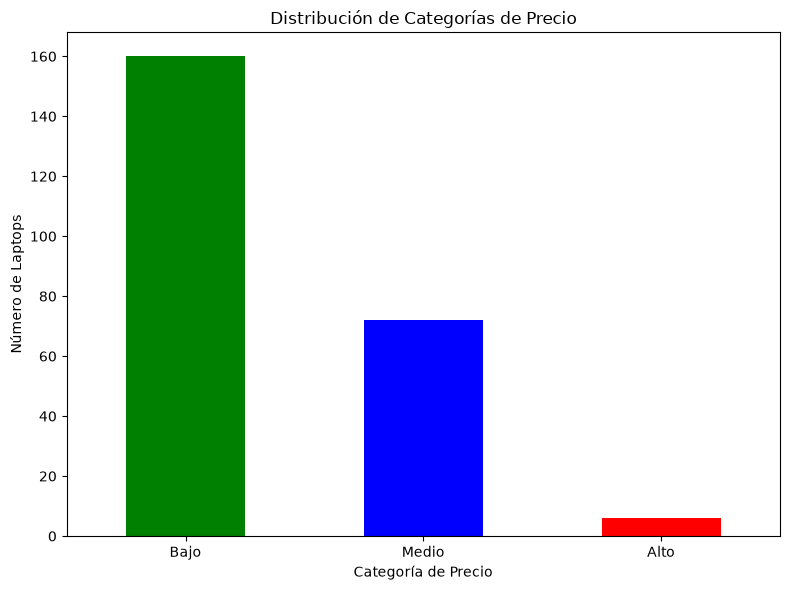

In [ ]:
# =============================================
# TAREA 5: Agrupamiento (Binning)
# =============================================

print("\n=== TAREA 5: AGRUPAMIENTO (BINNING) ===")

# Calcular el rango de precios para generar los bins
desde = df['Price'].min()
hasta = df['Price'].max()
print(f"Rango de precios: {desde} - {hasta} USD")

# Crear 3 bins homogéneos para clasificar los precios en Bajo, Medio y Alto
# np.linspace genera los puntos de corte equidistantes.
bins = np.linspace(desde, hasta, 4)
group_names = ['Bajo', 'Medio', 'Alto']

# Asignar cada precio a una de las categorías definidas
# include_lowest=True incluye el precio mínimo dentro de la primera categoría
df['Agrupamiento de precios'] = pd.cut(df['Price'], bins, labels=group_names, include_lowest=True)

# Mostrar cuántas laptops hay en cada categoría de precio
print("Distribución de categorías de precios:")
print(df['Agrupamiento de precios'].value_counts())

# Graficar la distribución de precios por categoría
ax = df['Agrupamiento de precios'].value_counts().plot(kind='bar', color=['green', 'blue', 'red'], figsize=(8, 6))
ax.set_title('Distribución de Categorías de Precio')
ax.set_xlabel('Categoría de Precio')
ax.set_ylabel('Número de Laptops')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('precios_binning.png')
plt.show()

In [ ]:
# =============================================
# TAREA 6: Variables ficticias o indicadoras (One-Hot Encoding)
# =============================================

print("\n=== TAREA 6: ONE-HOT ENCODING ===")

# Revisar los valores distintos de la columna Screen para saber qué categorías existen
print("Valores únicos en la columna Screen:")
print(df['Screen'].unique())

# Crear variables ficticias para cada valor de Screen.
# Cada valor único se convierte en una columna con 0 o 1 indicando su presencia.
dummies = pd.get_dummies(df['Screen'], prefix='Screen', drop_first=False)
print("Variables indicadoras creadas:")
print(dummies.head())

# Ajustar los nombres de columnas para que no contengan espacios y sean consistentes
dummies.rename(columns={'Screen_IPS Panel': 'Screen-IPS_panel', 
                         'Screen_Full HD': 'Screen-Full_HD'}, inplace=True)

# Eliminar la columna original Screen, ya que ahora se representa con las columnas binarias
df.drop('Screen', axis=1, inplace=True)

# Concatenar las columnas dummy al dataframe original
df = pd.concat([df, dummies], axis=1)

print("Columnas después de one-hot encoding:")
print(df.columns.tolist())


=== TAREA 6: ONE-HOT ENCODING ===
Valores únicos en la columna Screen:
<StringArray>
['IPS Panel', 'Full HD']
Length: 2, dtype: str
Variables indicadoras creadas:
   Screen_Full HD  Screen_IPS Panel
0           False              True
1            True             False
2            True             False
3           False              True
4            True             False
Columnas después de one-hot encoding:
['Manufacturer', 'Category', 'GPU', 'OS', 'CPU_core', 'Screen_Size_cm_original', 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'Weight_kg_original', 'Price', 'Screen_Size_in', 'Weight_lbs', 'CPU_frequency_norm', 'Agrupamiento de precios', 'Screen-Full_HD', 'Screen-IPS_panel']


In [ ]:
# =============================================
# VERIFICACIÓN FINAL
# =============================================

print("\n=== VERIFICACIÓN FINAL ===")

# Mostrar la estructura final del dataframe, tipos de datos y valores nulos restantes
print("Información final del dataset:")
print(df.info())

# Mostrar las primeras filas del dataset ya procesado para validar los cambios
print("\nPrimeras 5 filas del dataset procesado:")





=== VERIFICACIÓN FINAL ===
Información final del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Manufacturer             238 non-null    str     
 1   Category                 238 non-null    int64   
 2   GPU                      238 non-null    int64   
 3   OS                       238 non-null    int64   
 4   CPU_core                 238 non-null    int64   
 5   Screen_Size_cm_original  234 non-null    float64 
 6   CPU_frequency            238 non-null    float64 
 7   RAM_GB                   238 non-null    int64   
 8   Storage_GB_SSD           238 non-null    int64   
 9   Weight_kg_original       233 non-null    float64 
 10  Price                    238 non-null    int64   
 11  Screen_Size_in           234 non-null    float64 
 12  Weight_lbs               233 non-null    float64 
 13  CPU_frequency_nor